# Tutorial 3 - Reusing Sharable Archives

Sharable archives are designed to preserve the state of a completed or partially completed analysis in a portable form. 
Instead of transferring only raw trajectories, intermediate files, or isolated figures, an archive can capture the relevant pipeline objects, derived representations, and analysis results in a single reusable package. 
This makes it possible to distribute a well-defined analytical state across collaborators, computing environments, or publication supplements without requiring every step of the workflow to be recomputed from scratch.

An important consequence of this design is that archives should not be seen as static end products. 
Once an archive is loaded, it can serve as the starting point for further analysis, visualization, and method development. 
Previously generated results can be inspected immediately, while additional feature generation, dimensionality reduction, clustering, or plotting steps can be appended to the restored pipeline in the same way as in a freshly created project. 
In this sense, sharable archives support both reproducibility and continuity: they preserve prior work while still allowing the workflow to evolve.

In this tutorial, we therefore demonstrate a simple but important reuse scenario. 
We first download and load an existing archive, inspect the information already stored in it, and revisit selected plots from analysis done earlier. 
We then continue from the archived state by adding new coordinate-based features, constructing a new feature selection, performing PCA, running an additional clustering step, and visualizing the resulting low-dimensional representation. 
The example illustrates that a sharable archive can function not only as a vehicle for exchange, but also as a practical entry point for extending an analysis in a transparent and reproducible manner.

In [1]:
from mdxplain import PipelineManager
import urllib.request

Download a prepared archive file. This simulates receiving a sharable analysis package from somewhere else.

In [16]:
url = "https://proteinformatics.uni-leipzig.de/mdxplain/tutorial_test_pipeline.tar.zst"
target_path = "cache/tutorial_test_pipeline.tar.zst"

urllib.request.urlretrieve(url, target_path)
print("Download Done.")

Download Done.


Load the archive into `mdxplain`. After this step, we can inspect it and continue working with it.

In [4]:
loaded_pipeline_archive = PipelineManager.load_from_archive("cache/tutorial_test_pipeline.tar.zst")

Resource limits applied: cpu_affinity=14 cores, nice=15, io_priority=low, blas_threads=14


Print a compact summary of what is already stored in the archive.

In [5]:
loaded_pipeline_archive.print_info()

======= PIPELINE INFORMATION =======

--- Trajectory Data ---
Loaded 1 trajectories:
  [0] 2RJY_protein_simulation_run1: 10001 frames

--- Feature Data ---
=== Feature Information ===
Feature Types: 2 (distances, contacts)

--- distances ---
Trajectory 0:
=== FeatureData ===
Feature Type: Distances
Original Data: 10001 frames x 1953 features
Feature Metadata: 1953 feature definitions

--- contacts ---
Trajectory 0:
=== FeatureData ===
Feature Type: Contacts
Original Data: 10001 frames x 1953 features
Feature Metadata: 1953 feature definitions

--- Feature Selection Data ---
=== FeatureSelectorData Information ===
FeatureSelectorData Names: 1 (contacts_only)

--- contacts_only ---
=== FeatureSelectorData ===
Name: contacts_only
Feature Types: 1 (contacts)
Total Selections: 1
Reference Trajectory: 0
Matrix Columns: 1953
Selection Results: Available for 1 feature types (contacts)

--- Clustering Data ---
=== ClusteringData Information ===
ClusteringData Names: 1 (DPA_ContactKPC)

--- DPA_

Reuse one of the feature-importance plots that was saved with the archive.

ℹ️  depth=3 ≤ 4: Automatically using Grid mode


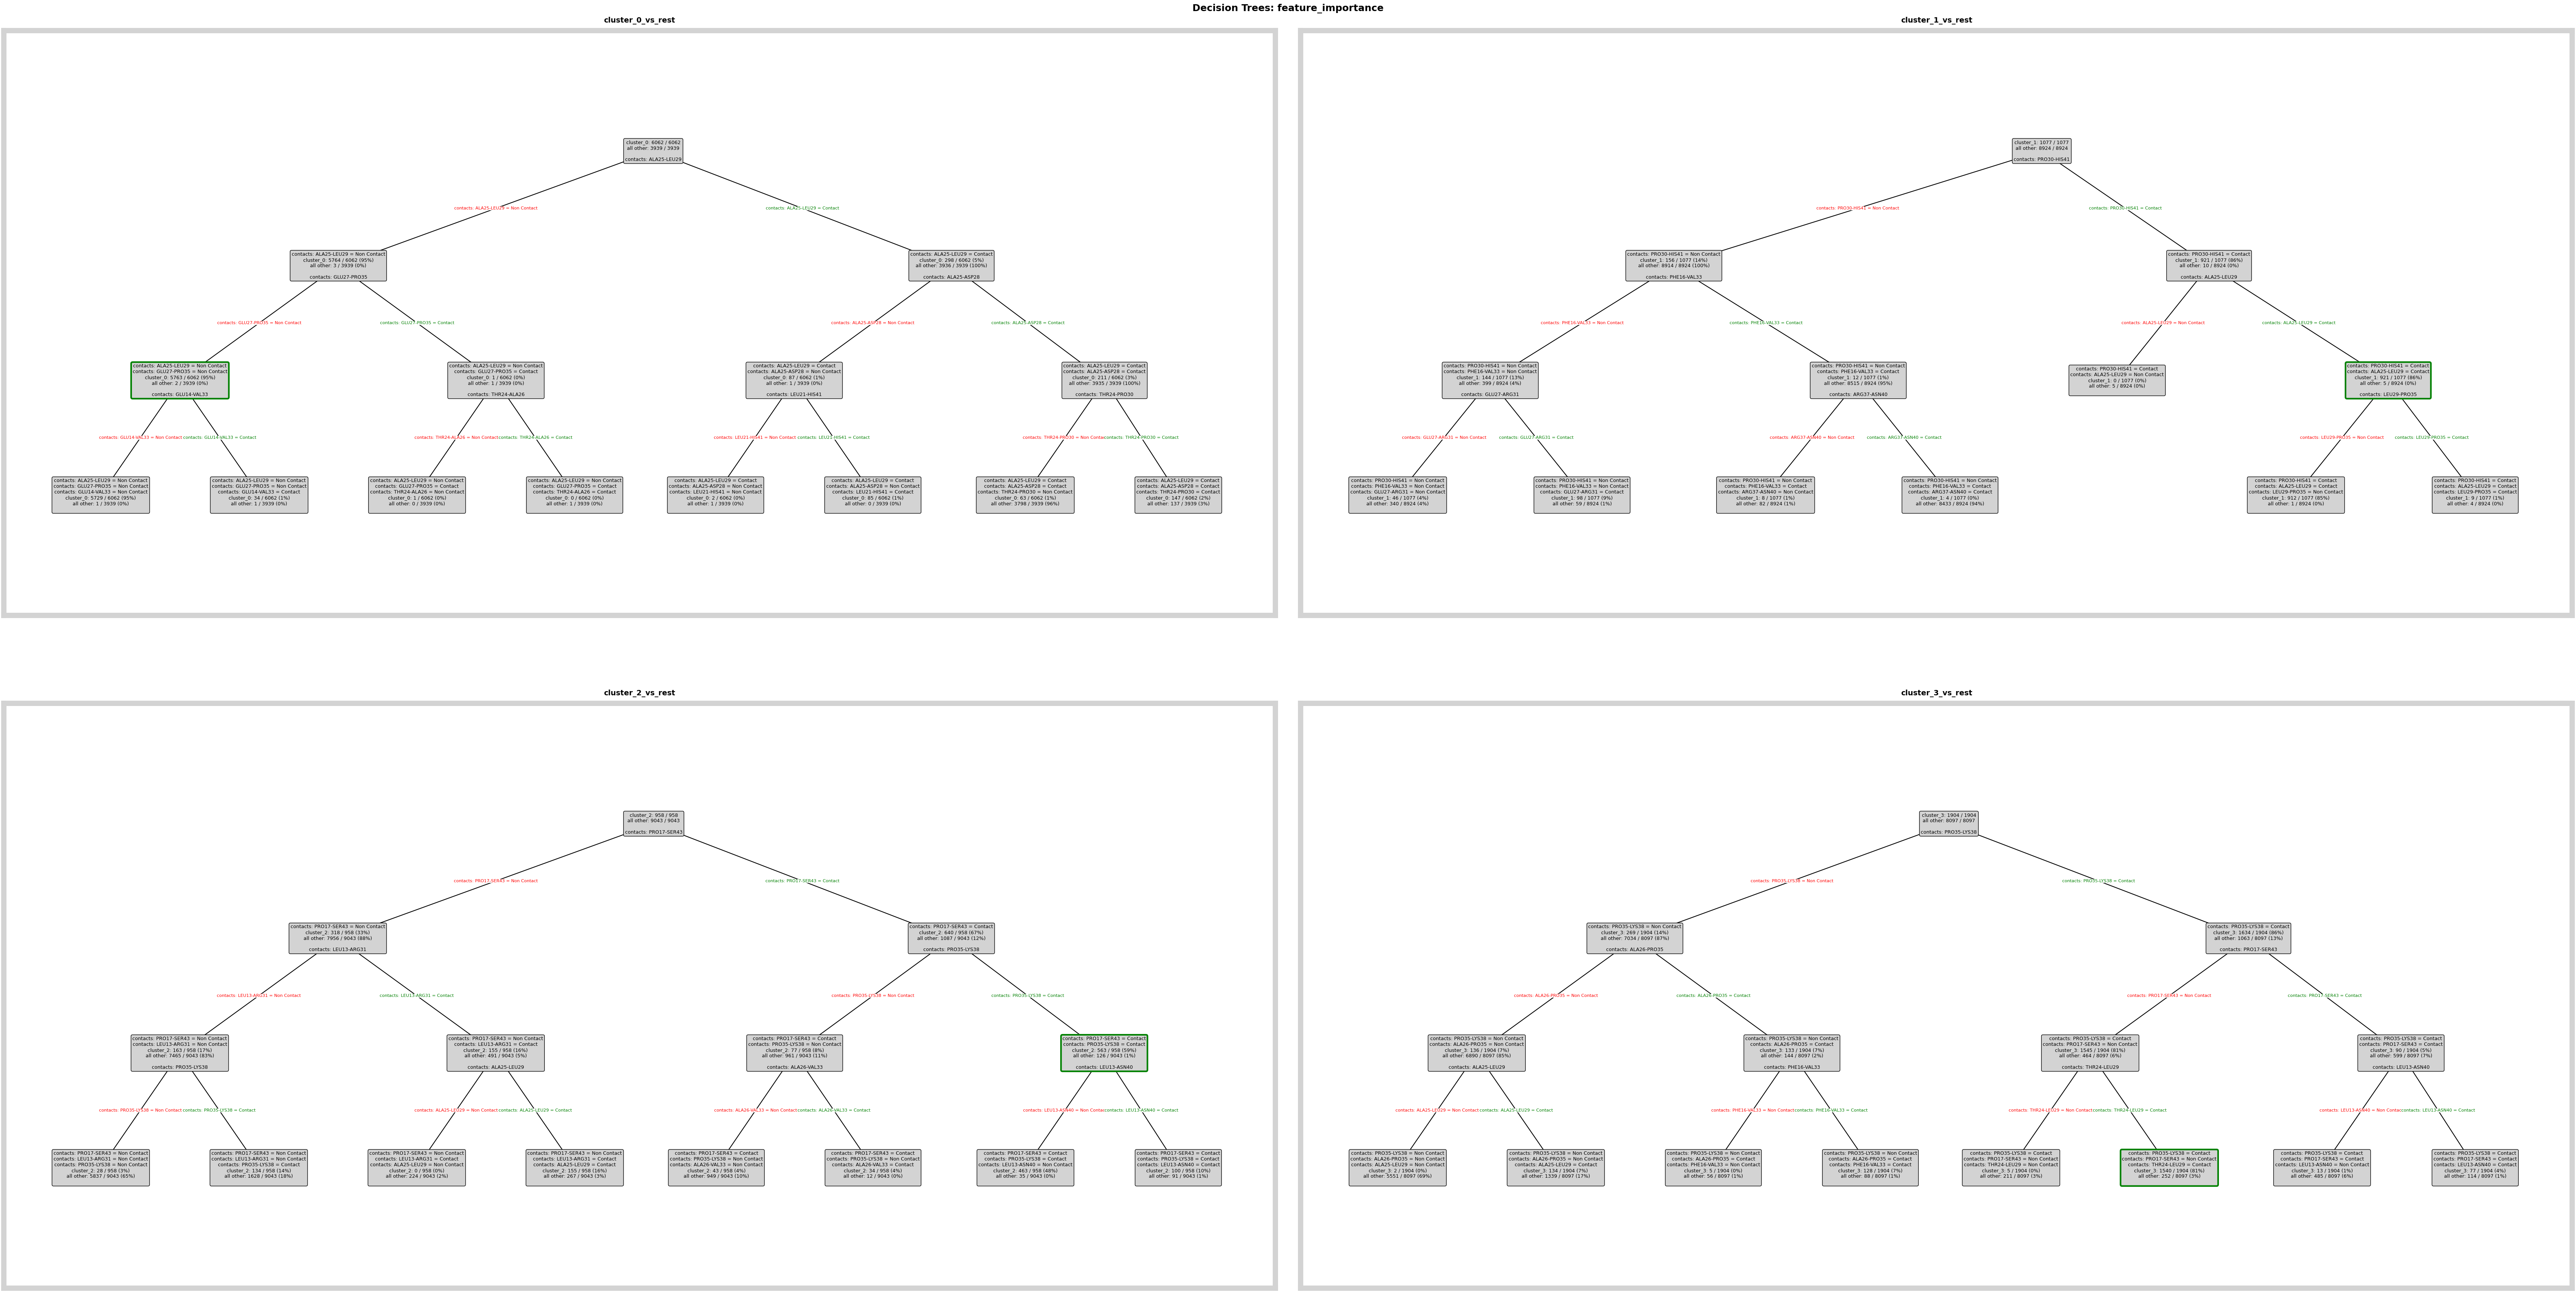

In [6]:
fig = loaded_pipeline_archive.plots.feature_importance.decision_trees(
    feature_importance_name="feature_importance",
)

Open a second archived feature-importance view.

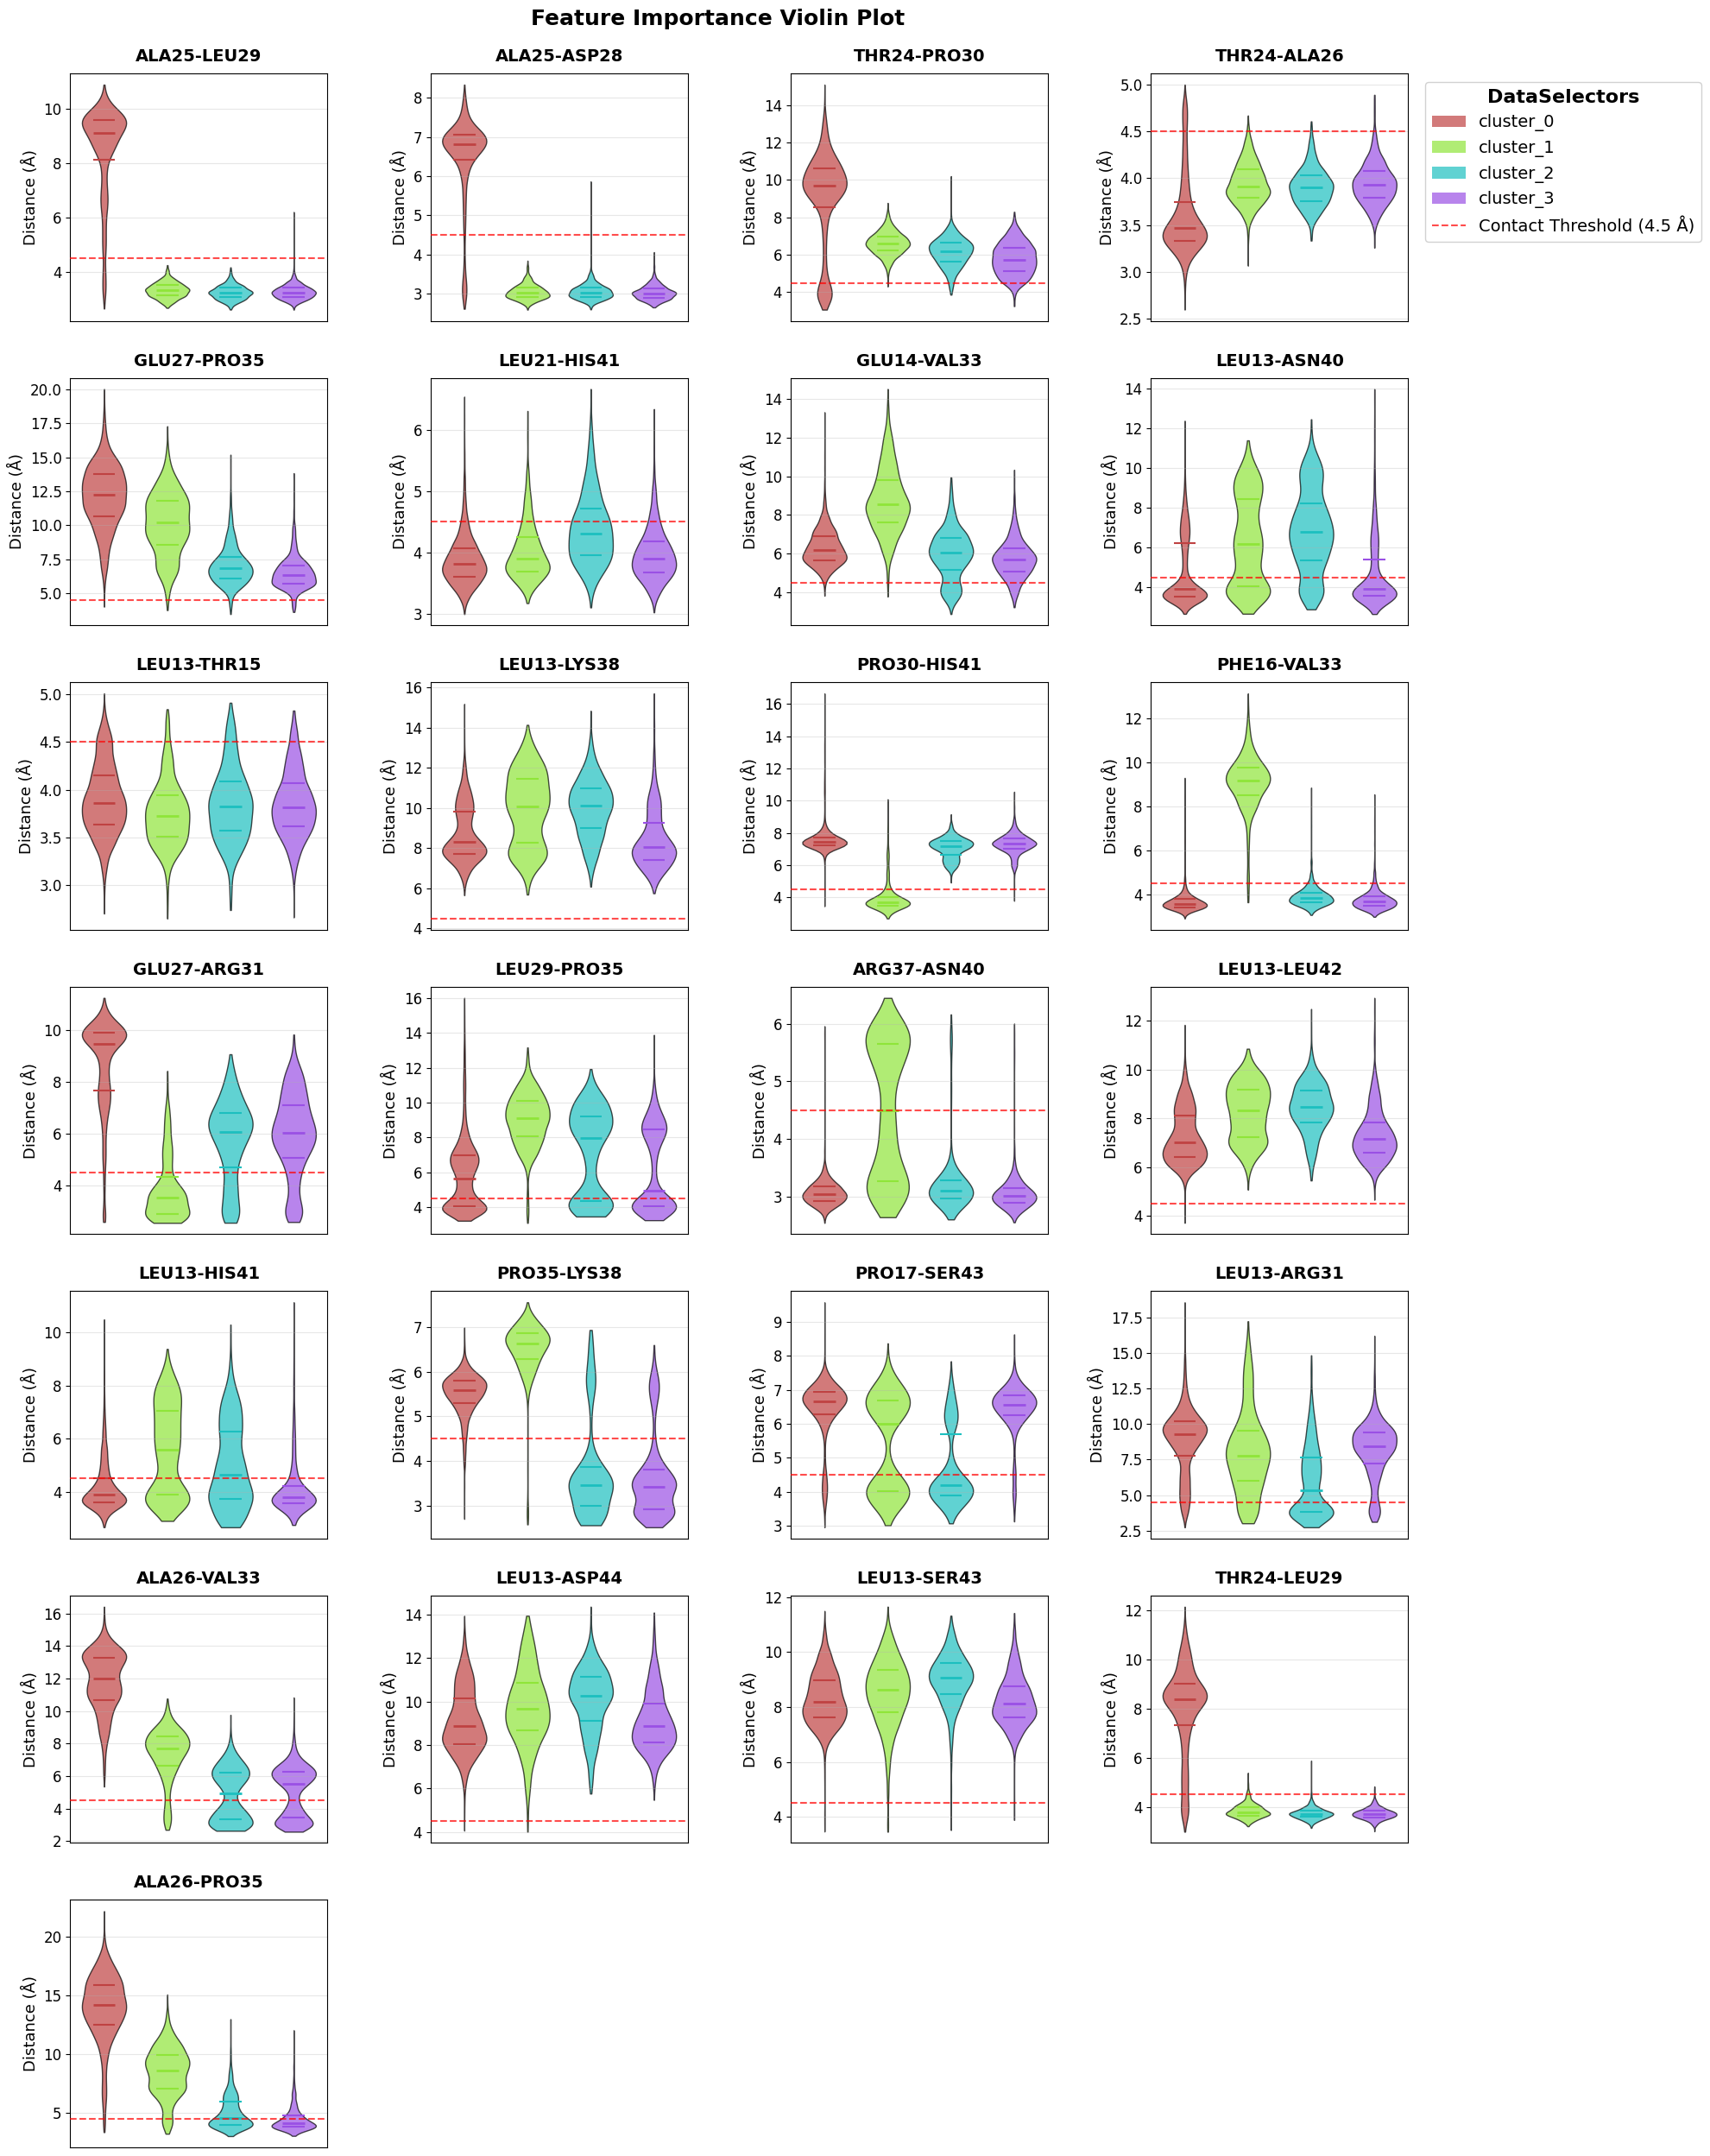

In [7]:
fig = loaded_pipeline_archive.plots.feature_importance.violins(
    feature_importance_name="feature_importance",
)

## Continue From The Archive

Now we extend the loaded archive with new analysis steps instead of only viewing saved results.

In [8]:
loaded_pipeline_archive.feature.add.coordinates()

Computing coordinates:   0%|          | 0/1 [00:00<?, ?trajectories/s]

Selected 64 atoms using selection 'name CA'


Computing coordinates: 100%|██████████| 1/1 [00:00<00:00,  1.95trajectories/s]


Define and select a new feature set based on coordinate-derived contacts.

In [9]:
loaded_pipeline_archive.feature_selector.create("ca_coordinates")
loaded_pipeline_archive.feature_selector.add.contacts("ca_coordinates", "all")
loaded_pipeline_archive.feature_selector.select("ca_coordinates")

Created feature selector: 'ca_coordinates'
Added to selector 'ca_coordinates': contacts -> 'all' (use_reduced=False, common_denominator=True, traj_selection=all, require_all_partners=False)
Applied feature selector 'ca_coordinates' with reference trajectory 0 successfully


Run PCA on the new feature set to obtain a compact representation.

In [10]:
loaded_pipeline_archive.decomposition.add.pca("ca_coordinates", n_components=4)

Decomposition 'pca' with name 'ca_coordinates_pca' for selection 'ca_coordinates' computed successfully. Data reduced from (10001, 1953) to (10001, 4).


Cluster the PCA representation and store the new clustering in the same pipeline object.

In [11]:
loaded_pipeline_archive.clustering.add.dpa(
    "ca_coordinates_pca", 
    Z=2.5,
    cluster_name="DPA_CAPCA",
)

Clustering 'DPA_CAPCA' completed successfully.
Found 5 clusters for 10001 frames.


First, look at the membership of the original clustering that already came with the archive.

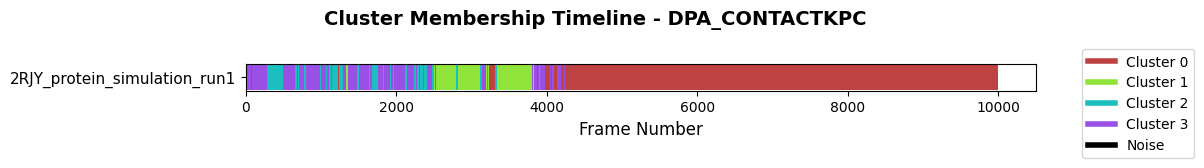

In [12]:
fig = loaded_pipeline_archive.plots.clustering.membership(
    clustering_name="DPA_ContactKPC",
)

Then inspect the membership of the new clustering that we just added.

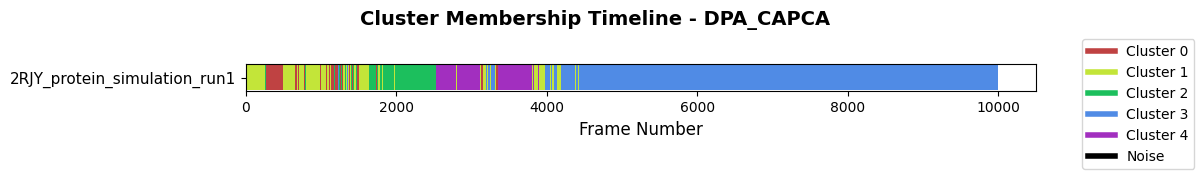

In [13]:
fig = loaded_pipeline_archive.plots.clustering.membership(
    clustering_name="DPA_CAPCA",
)

Plot the archived landscape to revisit the original low-dimensional view.

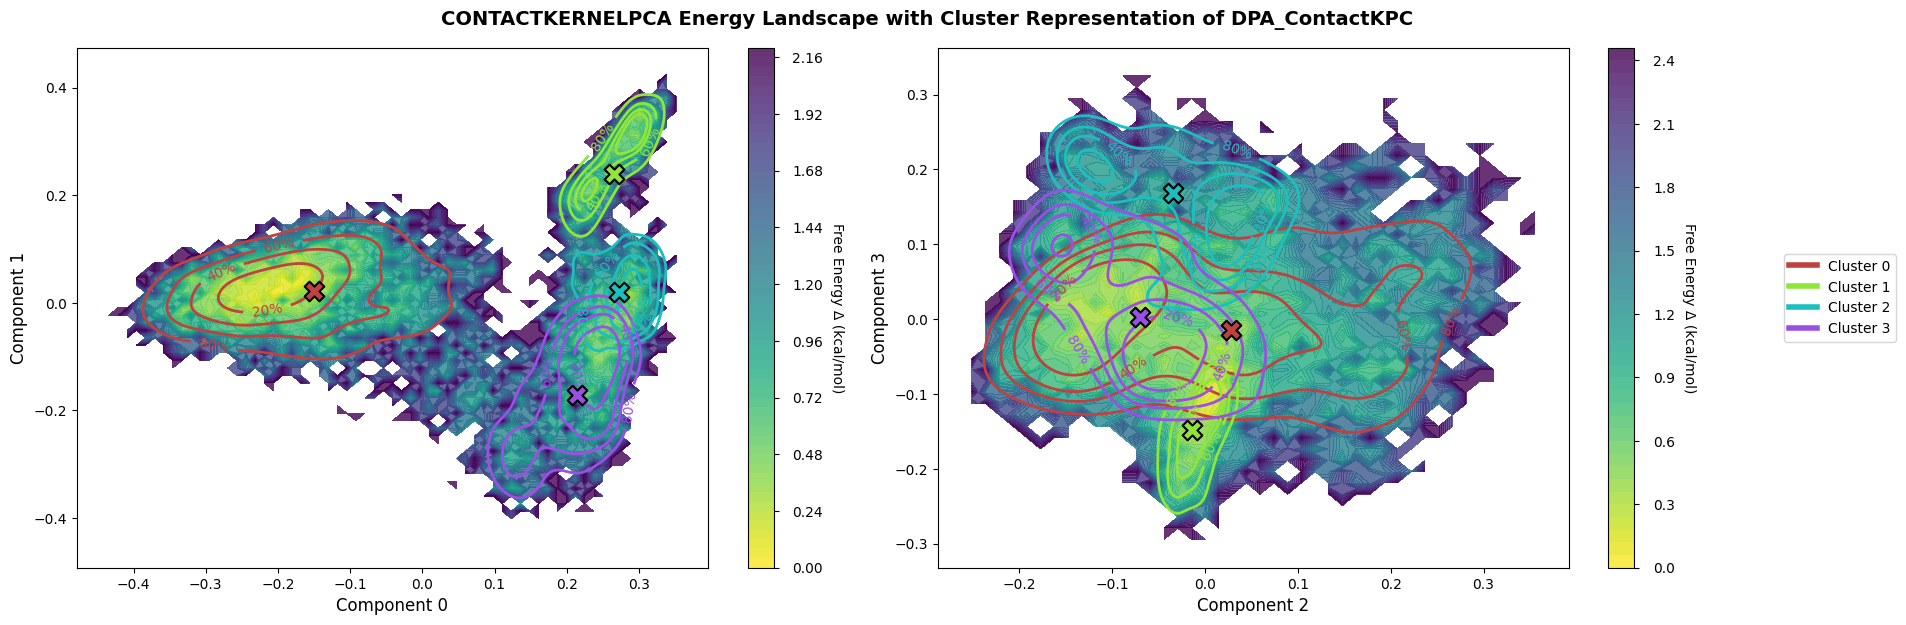

In [14]:
fig = loaded_pipeline_archive.plots.landscape(
    decomposition_name="ContactKernelPCA",
    dimensions=[0, 1, 2, 3],
    clustering_name="DPA_ContactKPC",
)

Finally, plot the landscape for the new PCA-based workflow created after loading the archive.

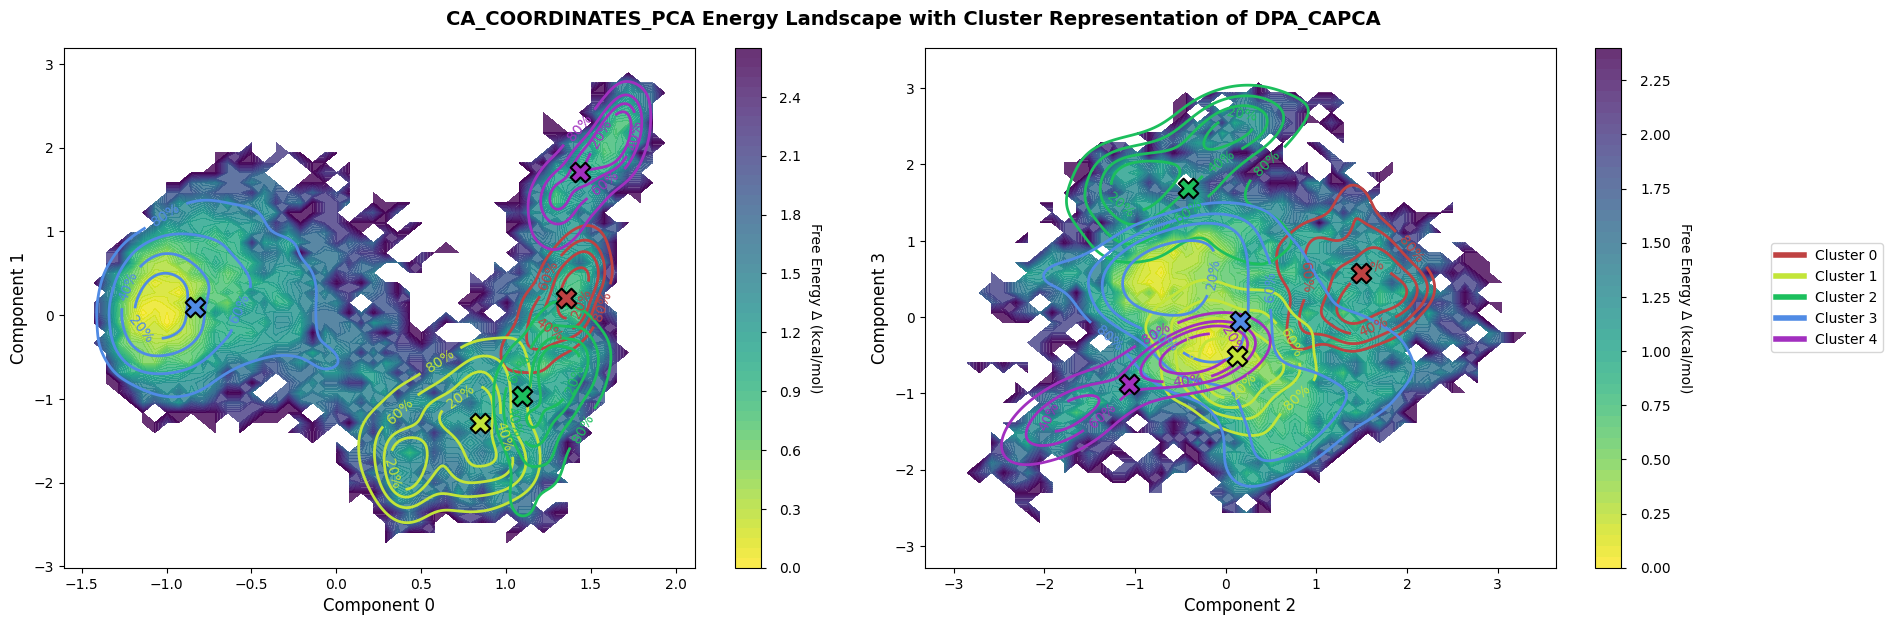

In [15]:
fig = loaded_pipeline_archive.plots.landscape(
    decomposition_name="ca_coordinates_pca",
    dimensions=[0, 1, 2, 3],
    clustering_name="DPA_CAPCA",
)